In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [71]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [72]:
df.shape

(13320, 9)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [74]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [75]:
df.duplicated().sum()

np.int64(529)

In [76]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [77]:
df[df.duplicated()].head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
971,Super built-up Area,Ready To Move,Haralur Road,3 BHK,NRowse,1464,3.0,2.0,56.0
1115,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1027,2.0,2.0,44.0
1143,Super built-up Area,Ready To Move,Vittasandra,2 BHK,Prlla C,1246,2.0,1.0,64.5
1290,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1194,2.0,2.0,47.0
1394,Super built-up Area,Ready To Move,Haralur Road,2 BHK,NaN,1027,2.0,2.0,44.0


In [78]:
df[df.duplicated()].shape

(529, 9)

df[df.duplicated()].head()

In [79]:
df["size"].value_counts().head(20)

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [80]:
df["bath"].value_counts().sort_index()

,count
bath,
1.0,788
2.0,6908
3.0,3286
4.0,1226
5.0,524
6.0,273
7.0,102
8.0,64
9.0,43


In [81]:
df["balcony"].value_counts().sort_index()

,count
balcony,
0.0,1029
1.0,4897
2.0,5113
3.0,1672


In [82]:
df["total_sqft"].unique()[:30]

array(['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300',
       '1310', '1020', '1800', '2785', '1000', '1100', '2250', '1175',
       '1180', '1540', '2770', '600', '1755', '2800', '1767', '510',
       '1250', '660', '1610', '1151', '1025', '2100 - 2850'], dtype=object)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [84]:
df_clean = df.copy()

In [85]:
df_clean = df_clean.drop("society", axis=1)

In [86]:
df_clean.columns

Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')

In [87]:
df_clean = df_clean.drop_duplicates()
df_clean.shape

(12752, 8)

In [88]:
df_clean.duplicated().sum()

np.int64(0)

In [89]:
df_clean = df_clean.dropna(subset=["location", "size"])
df_clean.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,57
balcony,589
price,0


In [90]:
df_clean["bhk"] = df_clean["size"].str.extract(r"(\d+)").astype(float)
df_clean[["size", "bhk"]].head(20)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [91]:
pd.to_numeric(df_clean["total_sqft"], errors="coerce").isna().sum()

np.int64(238)

In [92]:
df_clean.loc[
    pd.to_numeric(df_clean["total_sqft"], errors="coerce").isna(),
    "total_sqft"
].unique()
df_clean[["size", "bhk"]].head(20)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [93]:
pd.to_numeric(df_clean["total_sqft"], errors="coerce").isna().sum()

np.int64(238)

In [94]:
df_clean.loc[
    pd.to_numeric(df_clean["total_sqft"], errors="coerce").isna(),
    "total_sqft"
].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '4125Perch', '1120 - 1145',
       '4400 - 6640', '3090 - 5002', '4400 - 6800', '1160 - 1195',
       '1000Sq. Meter', '4000 - 5249', '1115 - 1130', '1100Sq. Yards',
       '520 - 645', '1000 - 1285', '3606 - 5091', '650 - 665',
       '633 - 666', '5.31Acres', '30Acres', '1445 - 1455', '884 - 1116',
       '850 - 1093', '1440 - 1884', '716Sq. Meter', '547.34 - 827.31',
       '580 - 650', '3425 - 3435', '1804 - 2273', '3630 - 3800',
       '660 - 670', '1500Sq. Meter', '620 - 933', '142.61Sq. Meter',
       '2695 - 2940', '1574Sq. Yards', '3450 - 3472', '1250 - 1305',
       '670 - 980', '1005.03 - 1252.49', '1004 - 1204', '361.33Sq. Yards',
       '645 - 936', '2710 - 3360', '2249.81 - 4112.19', '3436 - 3643',
       '2830 - 2882', '596 - 804', '1255 - 1863', '1300 - 1405',
       '117Sq. Yards', '934 - 1437', '9

In [95]:
def convert_to_sqft(value):
    value = str(value).strip()

    # Case 1: Range such as "2100 - 2850"
    if "-" in value:
        try:
            low, high = value.split("-")
            return (float(low.strip()) + float(high.strip())) / 2
        except:
            return np.nan

    # Case 2: Square meter
    if "Sq. Meter" in value:
        try:
            num = float(value.replace("Sq. Meter", "").strip())
            return num * 10.7639
        except:
            return np.nan

    # Case 3: Square yards
    if "Sq. Yards" in value:
        try:
            num = float(value.replace("Sq. Yards", "").strip())
            return num * 9
        except:
            return np.nan

    # Case 4: Acres
    if "Acres" in value:
        try:
            num = float(value.replace("Acres", "").strip())
            return num * 43560
        except:
            return np.nan

    # Case 5: Perch
    if "Perch" in value:
        try:
            num = float(value.replace("Perch", "").strip())
            return num * 272.25
        except:
            return np.nan

    # Case 6: Guntha
    if "Guntha" in value:
        try:
            num = float(value.replace("Guntha", "").strip())
            return num * 1089
        except:
            return np.nan

    # Case 7: Cents
    if "Cents" in value:
        try:
            num = float(value.replace("Cents", "").strip())
            return num * 435.6
        except:
            return np.nan

    # Case 8: Grounds
    if "Grounds" in value:
        try:
            num = float(value.replace("Grounds", "").strip())
            return num * 2400
        except:
            return np.nan

    # Case 9: Normal number
    try:
        return float(value)
    except:
        return np.nan

In [96]:
df_clean["total_sqft"] = df_clean["total_sqft"].apply(convert_to_sqft)

In [97]:
df_clean["total_sqft"].head(20)

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0
5,1170.0
6,2732.0
7,3300.0
8,1310.0
9,1020.0


In [98]:
df_clean["total_sqft"].isna().sum()

np.int64(0)

In [99]:
df_clean["bath"].value_counts().sort_index()

,count
bath,
1.0,762
2.0,6512
3.0,3174
4.0,1198
5.0,520
6.0,271
7.0,102
8.0,64
9.0,42


In [100]:
df_clean[df_clean["bath"] > 10][["size", "bath", "total_sqft", "price"]]

,size,bath,total_sqft,price
938,9 Bedroom,11.0,1260.0,290.0
1078,9 Bedroom,14.0,3300.0,500.0
1718,27 BHK,27.0,8000.0,230.0
1768,11 Bedroom,11.0,1200.0,170.0
1953,8 Bedroom,12.0,1200.0,110.0
1979,8 Bedroom,12.0,990.0,120.0
3096,10 BHK,12.0,12000.0,525.0
3379,19 BHK,16.0,2000.0,490.0
3609,16 BHK,16.0,10000.0,550.0
4684,43 Bedroom,40.0,2400.0,660.0


In [101]:
df_clean = df_clean[df_clean["total_sqft"] <= 10000]

In [102]:
df_clean.shape

(12694, 9)

In [103]:
df_clean["sqft_per_bhk"] = df_clean["total_sqft"] / df_clean["bhk"]

In [104]:
df_clean["price_per_sqft"] = (
    df_clean["price"] * 100000
) / df_clean["total_sqft"]

In [105]:
df_clean["price_per_sqft"].describe()

,price_per_sqft
count,1.269400e+04
mean,8.045306e+03
std,1.088339e+05
min,4.545455e+02
25%,4.300256e+03
50%,5.490734e+03
75%,7.407407e+03
max,1.200000e+07


In [106]:
df_clean.nlargest(10, "price_per_sqft")[
    ["location", "size", "total_sqft", "price", "price_per_sqft"]
]

,location,size,total_sqft,price,price_per_sqft
4086,Sarjapur Road,4 Bedroom,1.0,120.0,1.200000e+07
4972,Srirampuram,7 BHK,5.0,115.0,2.300000e+06
349,Suragajakkanahalli,3 Bedroom,11.0,74.0,6.727273e+05
1122,Grihalakshmi Layout,5 Bedroom,24.0,150.0,6.250000e+05
11558,Whitefield,4 Bedroom,60.0,218.0,3.633333e+05
1020,Weavers Colony,1 BHK,15.0,30.0,2.000000e+05
7657,Raghuvanahalli,1 BHK,425.0,750.0,1.764706e+05
5668,Judicial Layout,5 Bedroom,405.0,400.0,9.876543e+04
7088,Srirampuram,1 BHK,650.0,500.0,7.692308e+04
6421,Bommenahalli,4 Bedroom,2940.0,2250.0,7.653061e+04


In [107]:
df_clean.nsmallest(10, "price_per_sqft")[
    ["location", "size", "total_sqft", "price", "price_per_sqft"]
]

,location,size,total_sqft,price,price_per_sqft
872,Singapura Village,2 BHK,9900.0000,45.0,454.545455
11748,Begur,3 BHK,2400.0000,12.0,500.000000
4113,BTM Layout,3 BHK,1797.5713,10.0,556.306167
8391,Kengeri,1 BHK,1200.0000,14.0,1166.666667
2421,Basavanagara,4 Bedroom,2000.0000,25.0,1250.000000
3976,Chikkathoguru,1 BHK,1500.0000,19.5,1300.000000
5652,JP Nagar,2 BHK,1100.0000,15.0,1363.636364
4105,Indranagar 100ft road defence colony,5 BHK,5800.0000,80.0,1379.310345
9374,Yelahanka,1 BHK,1000.0000,14.0,1400.000000
7961,Hegde Nagar,4 BHK,2600.0000,40.0,1538.461538


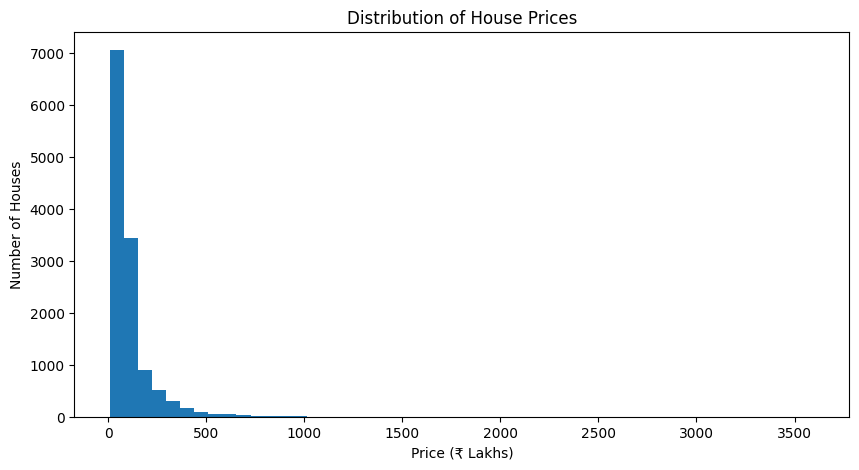

In [108]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean["price"], bins=50)

plt.xlabel("Price (₹ Lakhs)")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

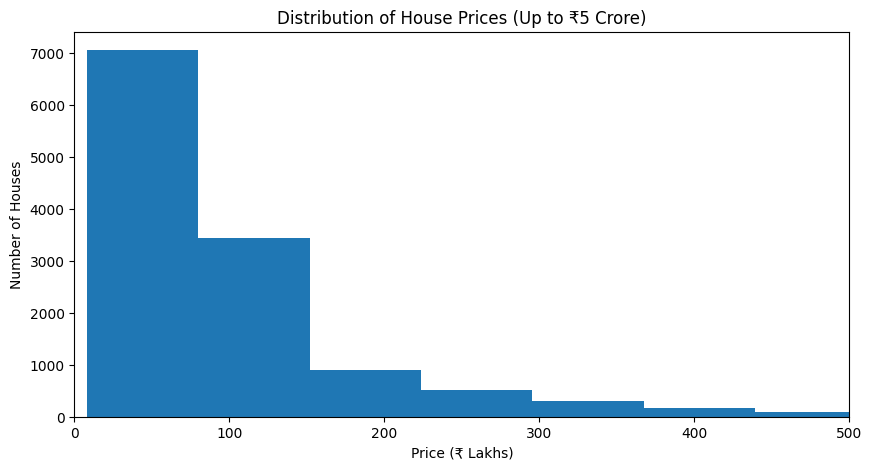

In [109]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean["price"], bins=50)

plt.xlim(0, 500)

plt.xlabel("Price (₹ Lakhs)")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices (Up to ₹5 Crore)")

plt.show()

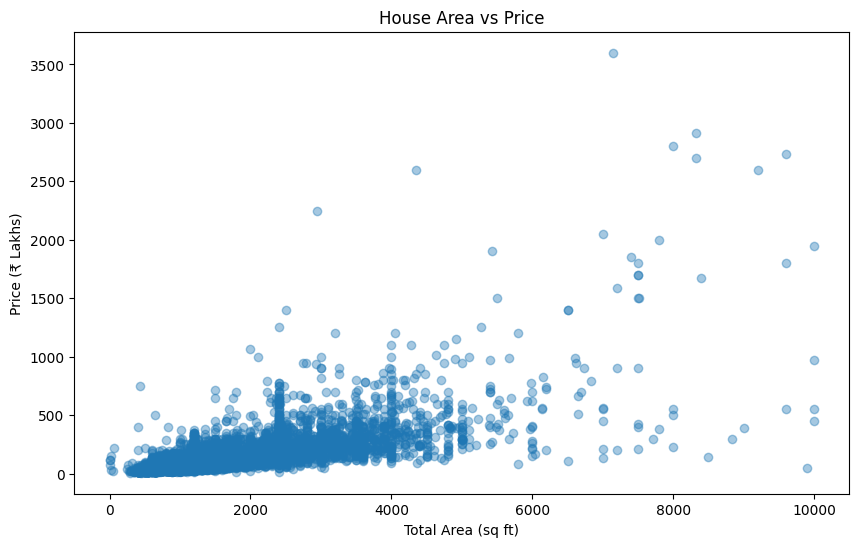

In [110]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["total_sqft"],
    df_clean["price"],
    alpha=0.4
)

plt.xlabel("Total Area (sq ft)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Area vs Price")

plt.show()

In [111]:
bhk_price = df_clean.groupby("bhk")["price"].mean()

bhk_price

,price
bhk,
1.0,44.288494
2.0,59.907478
3.0,112.253200
4.0,265.801406
5.0,281.900862
6.0,213.077626
7.0,203.989691
8.0,187.149425
9.0,242.788462


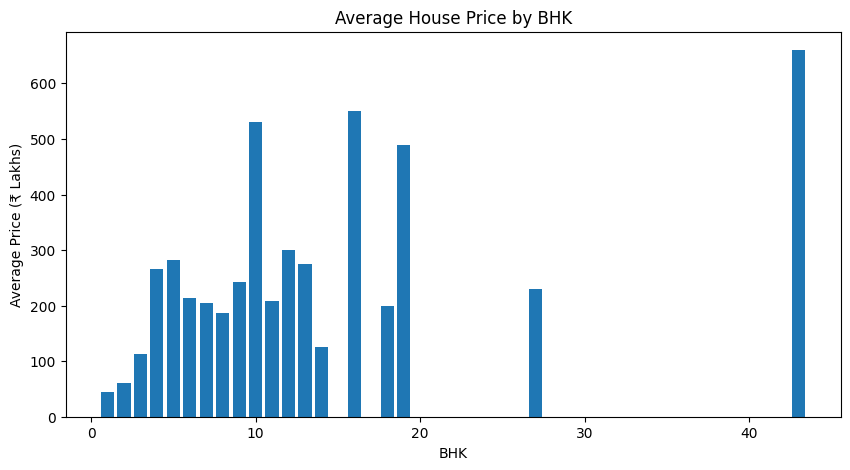

In [112]:
plt.figure(figsize=(10, 5))

plt.bar(bhk_price.index, bhk_price.values)

plt.xlabel("BHK")
plt.ylabel("Average Price (₹ Lakhs)")
plt.title("Average House Price by BHK")

plt.show()

In [113]:
bhk_price_common = (
    df_clean[df_clean["bhk"] <= 10]
    .groupby("bhk")["price"]
    .mean()
)

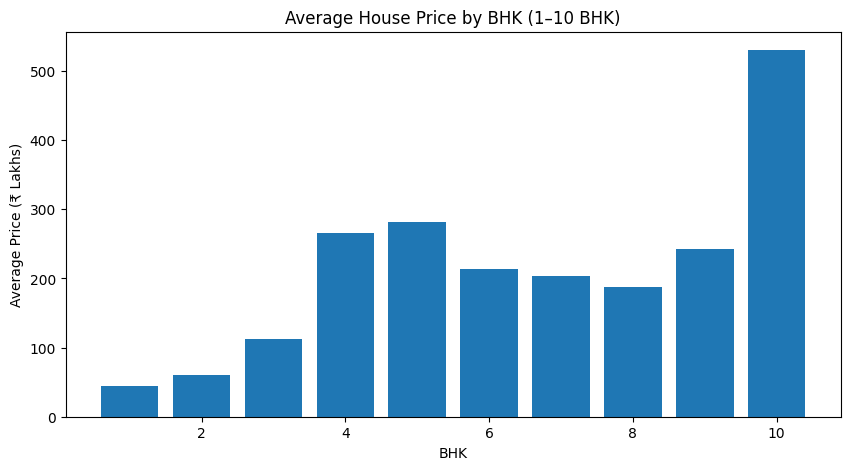

In [114]:
plt.figure(figsize=(10, 5))

plt.bar(bhk_price_common.index, bhk_price_common.values)

plt.xlabel("BHK")
plt.ylabel("Average Price (₹ Lakhs)")
plt.title("Average House Price by BHK (1–10 BHK)")

plt.show()

In [115]:
df_clean[df_clean["bhk"] <= 10]["bhk"].value_counts().sort_index()

,count
bhk,
1.0,631
2.0,5215
3.0,4633
4.0,1387
5.0,348
6.0,219
7.0,97
8.0,87
9.0,52


In [116]:
location_count = df_clean["location"].value_counts()

location_count.head(20)

,count
location,
Whitefield,520
Sarjapur Road,377
Electronic City,286
Kanakpura Road,240
Thanisandra,229
Yelahanka,207
Marathahalli,169
Hebbal,161
Raja Rajeshwari Nagar,159


In [117]:
top_locations = location_count.head(10).index

location_price = (
    df_clean[df_clean["location"].isin(top_locations)]
    .groupby("location")["price"]
    .mean()
    .sort_values()
)

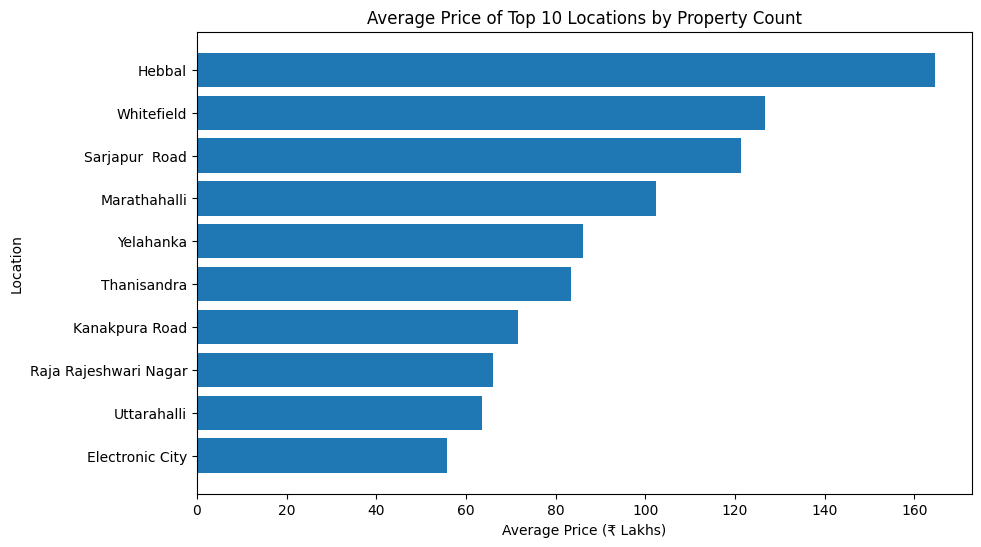

In [118]:
plt.figure(figsize=(10, 6))

plt.barh(location_price.index, location_price.values)

plt.xlabel("Average Price (₹ Lakhs)")
plt.ylabel("Location")
plt.title("Average Price of Top 10 Locations by Property Count")

plt.show()

In [119]:
location_stats = df_clean["location"].value_counts()

valid_locations = location_stats[location_stats >= 20].index

In [120]:
location_pps = (
    df_clean[df_clean["location"].isin(valid_locations)]
    .groupby("location")["price_per_sqft"]
    .mean()
    .sort_values(ascending=False)
)

In [121]:
location_pps.head(10)

,price_per_sqft
location,
Sarjapur Road,38043.830181
2nd Stage Nagarbhavi,16819.074074
Indira Nagar,14053.212672
Rajaji Nagar,13929.256002
Malleshwaram,13775.880075
Basaveshwara Nagar,11722.634950
Basavangudi,11224.833507
Ulsoor,10610.186393
Koramangala,10477.200883


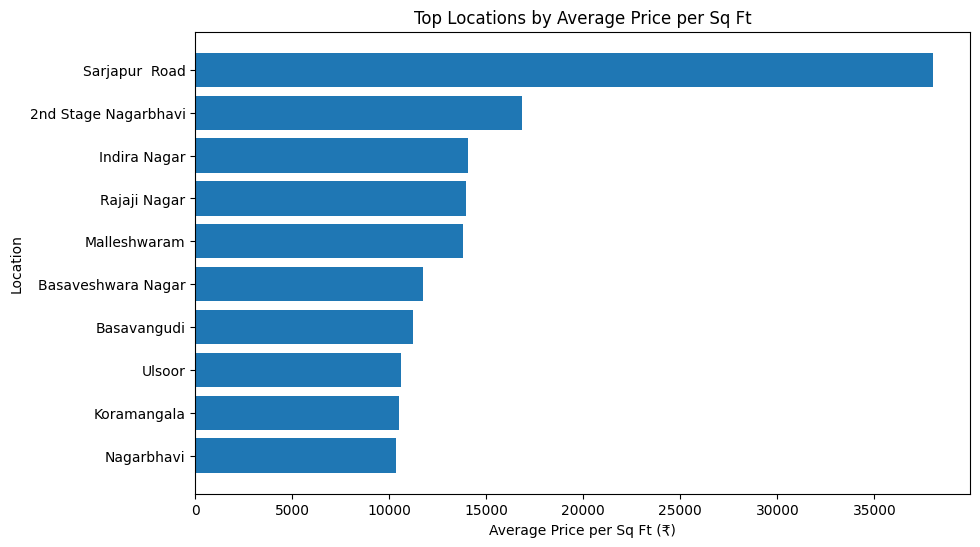

In [122]:
plt.figure(figsize=(10, 6))

top_pps = location_pps.head(10)

plt.barh(
    top_pps.index[::-1],
    top_pps.values[::-1]
)

plt.xlabel("Average Price per Sq Ft (₹)")
plt.ylabel("Location")
plt.title("Top Locations by Average Price per Sq Ft")

plt.show()

In [123]:
numeric_features = [
    "total_sqft",
    "bath",
    "bhk",
    "price",
    "sqft_per_bhk",
    "price_per_sqft"
]

correlation = df_clean[numeric_features].corr()

correlation

,total_sqft,bath,bhk,price,sqft_per_bhk,price_per_sqft
total_sqft,1.000000,0.523623,0.451859,0.707367,0.670879,-0.011489
bath,0.523623,1.000000,0.898708,0.461202,-0.054662,0.030776
bhk,0.451859,0.898708,1.000000,0.399609,-0.200199,0.030762
price,0.707367,0.461202,0.399609,1.000000,0.418172,0.029188
sqft_per_bhk,0.670879,-0.054662,-0.200199,0.418172,1.000000,-0.031323
price_per_sqft,-0.011489,0.030776,0.030762,0.029188,-0.031323,1.000000


In [124]:
correlation["price"].sort_values(ascending=False)

,price
price,1.000000
total_sqft,0.707367
bath,0.461202
sqft_per_bhk,0.418172
bhk,0.399609
price_per_sqft,0.029188


In [125]:
df_clean["location"] = df_clean["location"].str.strip()

In [126]:
df_clean["location"].nunique()

1284

In [127]:
X = df_clean[
    ["location", "total_sqft", "bhk", "bath"]
]

y = df_clean["price"]

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10155
Testing samples: 2539


In [129]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["location"]

numerical_features = [
    "total_sqft",
    "bhk",
    "bath"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [134]:
ml_features = [
    "location",
    "total_sqft",
    "bhk",
    "bath",
    "sqft_per_bhk",
    "price"
]

df_ml = df_clean[ml_features].dropna().copy()

print("Rows available for ML:", len(df_ml))
print("Missing values:")
print(df_ml.isnull().sum())

Rows available for ML: 12637
Missing values:
location        0
total_sqft      0
bhk             0
bath            0
sqft_per_bhk    0
price           0
dtype: int64


In [135]:
X = df_clean[
    ["location", "total_sqft", "bhk", "bath"]
]

y = df_clean["price"]

In [136]:
X = df_ml[
    ["location", "total_sqft", "bhk", "bath"]
]

y = df_ml["price"]

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10109
Testing samples: 2528


In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["location"]

numerical_features = [
    "total_sqft",
    "bhk",
    "bath"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [139]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [140]:
y_pred_linear = linear_model.predict(X_test)

In [141]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred_linear[:10]
})

comparison

,Actual Price,Predicted Price
0,69.61,58.957751
1,56.74,47.361007
2,53.00,62.274585
3,47.00,48.475714
4,45.00,48.818838
5,80.00,119.195981
6,90.00,-14.706907
7,35.25,60.804462
8,46.29,86.740447
9,180.00,157.955272


In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae_linear:.2f} Lakhs")
print(f"RMSE : {rmse_linear:.2f} Lakhs")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Results
-------------------------
MAE  : 43.71 Lakhs
RMSE : 118.63 Lakhs
R²   : 0.4679


In [143]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [144]:
y_pred_rf = random_forest_model.predict(X_test)

In [145]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print(f"MAE  : {mae_rf:.2f} Lakhs")
print(f"RMSE : {rmse_rf:.2f} Lakhs")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
--------------------
MAE  : 33.78 Lakhs
RMSE : 117.76 Lakhs
R²   : 0.4756


In [146]:
X = df_ml[
    ["location", "total_sqft", "bhk", "bath", "sqft_per_bhk"]
]

y = df_ml["price"]

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [148]:
categorical_features = ["location"]

numerical_features = [
    "total_sqft",
    "bhk",
    "bath",
    "sqft_per_bhk"
]

In [149]:
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "location",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [150]:
final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_final),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

final_rf_model.fit(X_train, y_train)

print("Final Random Forest trained successfully!")

Final Random Forest trained successfully!


In [151]:
y_pred_final = final_rf_model.predict(X_test)

In [152]:
mae_final = mean_absolute_error(y_test, y_pred_final)

rmse_final = np.sqrt(
    mean_squared_error(y_test, y_pred_final)
)

r2_final = r2_score(y_test, y_pred_final)

print("Final Random Forest Results")
print("---------------------------")
print(f"MAE  : {mae_final:.2f} Lakhs")
print(f"RMSE : {rmse_final:.2f} Lakhs")
print(f"R²   : {r2_final:.4f}")

Final Random Forest Results
---------------------------
MAE  : 33.95 Lakhs
RMSE : 118.78 Lakhs
R²   : 0.4665


In [153]:
def predict_house_price(location, total_sqft, bhk, bath):

    sqft_per_bhk = total_sqft / bhk

    input_data = pd.DataFrame({
        "location": [location],
        "total_sqft": [total_sqft],
        "bhk": [bhk],
        "bath": [bath],
        "sqft_per_bhk": [sqft_per_bhk]
    })

    prediction = final_rf_model.predict(input_data)[0]

    return prediction

In [155]:
predicted_price = predict_house_price(
    location="Whitefield",
    total_sqft=1200,
    bhk=2,
    bath=2
)

print(f"Predicted House Price: ₹{predicted_price:.2f} Lakhs")

Predicted House Price: ₹48.68 Lakhs


In [154]:
predicted_price = predict_house_price(
    location="Indira Nagar",
    total_sqft=1500,
    bhk=3,
    bath=2
)

print(f"Predicted House Price: ₹{predicted_price:.2f} Lakhs")

Predicted House Price: ₹105.92 Lakhs


In [156]:
import joblib

joblib.dump(final_rf_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [157]:
loaded_model = joblib.load("house_price_model.pkl")

test_prediction = loaded_model.predict(
    pd.DataFrame({
        "location": ["Whitefield"],
        "total_sqft": [1200],
        "bhk": [2],
        "bath": [2],
        "sqft_per_bhk": [600]
    })
)

print(f"Prediction: ₹{test_prediction[0]:.2f} Lakhs")

Prediction: ₹48.68 Lakhs


In [158]:
import os

print("Model exists:", os.path.exists("house_price_model.pkl"))

if os.path.exists("house_price_model.pkl"):
    print("✅ house_price_model.pkl is ready!")
else:
    print("❌ Model file not found")

Model exists: True
✅ house_price_model.pkl is ready!


In [159]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>